In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("customer_segmentation.csv")

In [4]:
df = df.dropna()
df['Age'] = 2024 - df['Year_Birth']
features = [
    'Age',
    'Income',
    'Recency',
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds',
    'NumWebPurchases',
    'NumCatalogPurchases',
    'NumStorePurchases',
    'NumWebVisitsMonth'
]

df_selected = df[features]


In [5]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler() 
scaled_data = scaler.fit_transform(df_selected)

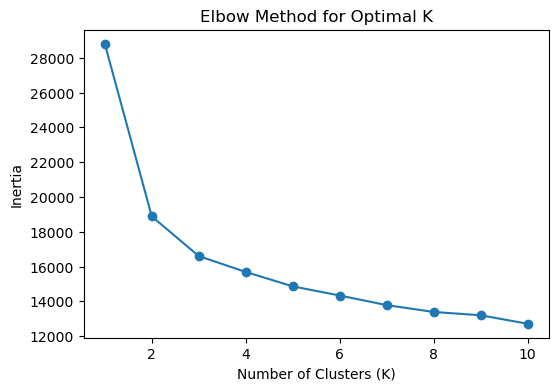

In [7]:
from sklearn.cluster import KMeans 
inertia = [] 
for k in range(1, 11): 
    km = KMeans(n_clusters=k) 
    km.fit(scaled_data) 
    inertia.append(km.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_data)


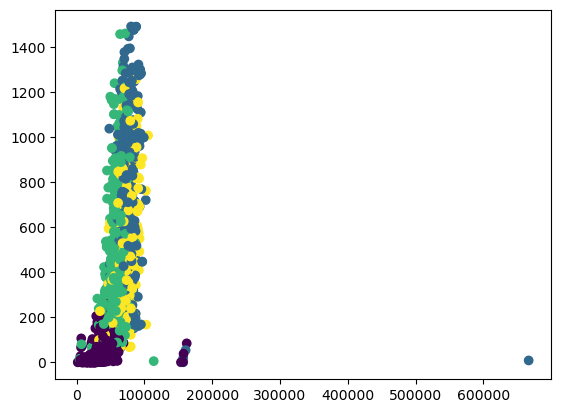

In [10]:
plt.scatter(df['Income'], df['MntWines'], c=df['Cluster'])